<a href="https://colab.research.google.com/github/LOVELY1907/SAP_AI-ML-DL/blob/main/03_Deep_Learning/ANN2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [ ]:
#data Ingestion
df = pd.read_csv("/content/patient_churn_dataset.csv")

In [ ]:
df.sample(2)

,Patient_ID,Age,Gender,Tenure_Months,Visits_Last_Year,Chronic_Disease,Insurance_Type,Satisfaction_Score,Total_Bill_Amount,Missed_Appointments,Churn
364,365,66,Male,13,4,No,NaN,3.2,715.98,1,0
412,413,58,Female,4,2,Yes,NaN,2.2,13745.84,0,0


In [ ]:
df.shape

(500, 11)

In [ ]:
def Data_cleaning(df):
  #null values
  null_values = df.isnull().sum()
  print(null_values)
  #duplicate values
  duplicate_values = df.duplicated().sum()
  print(duplicate_values)
  #information of data
  df.info()
  #describe
  df.describe()

In [ ]:
#calling function
Data_cleaning(df)

Patient_ID               0
Age                      0
Gender                   0
Tenure_Months            0
Visits_Last_Year         0
Chronic_Disease          0
Insurance_Type         150
Satisfaction_Score       0
Total_Bill_Amount        0
Missed_Appointments      0
Churn                    0
dtype: int64
0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Patient_ID           500 non-null    int64  
 1   Age                  500 non-null    int64  
 2   Gender               500 non-null    object 
 3   Tenure_Months        500 non-null    int64  
 4   Visits_Last_Year     500 non-null    int64  
 5   Chronic_Disease      500 non-null    object 
 6   Insurance_Type       350 non-null    object 
 7   Satisfaction_Score   500 non-null    float64
 8   Total_Bill_Amount    500 non-null    float64
 9   Missed_Appointments  500 non

In [ ]:
#removing the patient Id
if "Patient_ID" in df.columns:
  df.drop("Patient_ID",axis=1,inplace=True)

In [ ]:
df.columns

Index(['Age', 'Gender', 'Tenure_Months', 'Visits_Last_Year', 'Chronic_Disease',
       'Insurance_Type', 'Satisfaction_Score', 'Total_Bill_Amount',
       'Missed_Appointments', 'Churn'],
      dtype='object')

In [ ]:
df.columns.tolist()

['Age',
 'Gender',
 'Tenure_Months',
 'Visits_Last_Year',
 'Chronic_Disease',
 'Insurance_Type',
 'Satisfaction_Score',
 'Total_Bill_Amount',
 'Missed_Appointments',
 'Churn']

In [ ]:
#pipeline(1st)
x = df.drop('Churn',axis=1)
y = df['Churn']

In [ ]:
#pipeline(2nd)
numerical_cols = x.select_dtypes(include=['int64','float64']).columns
categorical_cols = x.select_dtypes(include=["object"]).columns


In [ ]:
numerical_cols.tolist()

['Age',
 'Tenure_Months',
 'Visits_Last_Year',
 'Satisfaction_Score',
 'Total_Bill_Amount',
 'Missed_Appointments']

In [ ]:
from sklearn.impute import SimpleImputer
si = SimpleImputer(strategy='most_frequent')

In [ ]:
x[['Insurance_Type']] = si.fit_transform(
    x[['Insurance_Type']])

In [ ]:

ohe= OneHotEncoder(sparse_output=False)
x['Gender'] = ohe.fit_transform(x[['Gender']])
x['Chronic_Disease'] = ohe.fit_transform(x[['Chronic_Disease']])
x['Insurance_Type'] = ohe.fit_transform(x[['Insurance_Type']])

In [ ]:
df.isnull().sum()

,0
Age,0
Gender,0
Tenure_Months,0
Visits_Last_Year,0
Chronic_Disease,0
Insurance_Type,150
Satisfaction_Score,0
Total_Bill_Amount,0
Missed_Appointments,0
Churn,0


In [ ]:
x['Insurance_Type'].isnull().sum()

np.int64(0)

In [ ]:
num_columns_transformer = Pipeline(
    steps =[
        ('scaler', StandardScaler())
    ]
)
categorical_transformer = Pipeline(
    steps = [
        ('encoding', OneHotEncoder(sparse_output=False))
    ]
)

In [ ]:
preprocessor = ColumnTransformer(
    transformers =[
        ('categorical',
         categorical_transformer,categorical_cols),
        ('numerical',
         num_columns_transformer,numerical_cols)
    ]
)

In [ ]:
model = Pipeline(
    steps =[
        ('preprocessor',preprocessor),
        ('classifier',LogisticRegression(max_iter=1000))
    ]
)

In [ ]:
#training as testing
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=100,stratify=y)

In [ ]:
#model pipeline training
model.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  Pipeline(steps=[('encoding',
                                                                   OneHotEncoder(sparse_output=False))]),
                                                  Index(['Gender', 'Chronic_Disease', 'Insurance_Type'], dtype='object')),
                                                 ('numerical',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Age', 'Tenure_Months', 'Visits_Last_Year', 'Satisfaction_Score',
       'Total_Bill_Amount', 'Missed_Appointments'],
      dtype='object'))])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,model.predict(x_test))

0.75

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
knn = KNeighborsClassifier(n_neighbors=3,metric='euclidean')


In [ ]:
num_columns_transformer1 = Pipeline(
    steps =[
        ('scaler', StandardScaler())
    ]
)
categorical_transformer1 = Pipeline(
    steps = [
        ('encoding', OneHotEncoder(sparse_output=False))
    ]
)

In [ ]:
preprocessor = ColumnTransformer(
    transformers =[
        ('categorical',
         categorical_transformer,categorical_cols),
        ('numerical',
         num_columns_transformer,numerical_cols)
    ]
)

In [ ]:
model = Pipeline(
    steps =[
        ('preprocessor',preprocessor),
        ('classifier',KNeighborsClassifier(n_neighbors=3,metric='euclidean'))
    ]
)

In [ ]:
#training as testing
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=100,stratify=y)

In [ ]:
#model pipeline training
model.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  Pipeline(steps=[('encoding',
                                                                   OneHotEncoder(sparse_output=False))]),
                                                  Index(['Gender', 'Chronic_Disease', 'Insurance_Type'], dtype='object')),
                                                 ('numerical',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Age', 'Tenure_Months', 'Visits_Last_Year', 'Satisfaction_Score',
       'Total_Bill_Amount', 'Missed_Appointments'],
      dtype='object'))])),
                ('classifier',
                 KNeighborsClassifier(metric='euclidean', n_neighbors=3))])

In [ ]:
accuracy_score(y_test,model.predict(x_test))

0.65

In [ ]:
from sklearn.model_selection import cross_val_score

In [ ]:
Score=cross_val_score(model,x,y,cv=5)
mean=Score.mean()
max=Score.max()
min=Score.min()
print(mean)
print(max)
print(min)

0.672
0.74
0.58


In [ ]:
Score

array([0.69, 0.7 , 0.65, 0.74, 0.58])

In [ ]:
accuracy_score(y_test,model.predict(x_test))

0.65

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential, Model

In [ ]:
from sklearn.impute import SimpleImputer
si = SimpleImputer(strategy='most_frequent')

In [ ]:

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
x_train.shape[1]

9

In [ ]:
#creating a ANN network
ANN1 = Sequential()
#input layer
ANN1.add(layers.Dense(64, activation='relu',input_shape=(x_train.shape[1],)))

#Hidden layer
ANN1.add(layers.Dense(32, activation='relu'))

#output layer
ANN1.add(layers.Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
ANN1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

# Reconstruct X and y correctly from the original dataframe
# Assuming df is the dataframe after 'Patient_ID' removal
X = df.drop('Churn', axis=1).copy()
y = df['Churn']

# Impute 'Insurance_Type' first, as done previously
si = SimpleImputer(strategy='most_frequent')
X['Insurance_Type'] = si.fit_transform(X[['Insurance_Type']]).flatten()

# Identify numerical and categorical columns from the current X
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns

# Create preprocessing pipelines for numerical and categorical features
numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Create a column transformer to apply different transformations to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ],
    remainder='passthrough' # Keep other columns (if any) as they are
)

# Apply the preprocessing to X
X_processed = preprocessor.fit_transform(X)

# Split the preprocessed data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42)

# Ensure y_train is a numpy array if it's still a pandas Series, for consistency with Keras
if isinstance(y_train, pd.Series):
    y_train = y_train.values

# Re-create and compile the ANN model to ensure the input shape matches the processed data
# This assumes the original model structure was intended. The input_shape will now be dynamic.
ANN1 = Sequential()
ANN1.add(layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
ANN1.add(layers.Dense(32, activation='relu'))
ANN1.add(layers.Dense(1, activation='sigmoid'))

ANN1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Training Code for Neural Network
ANN1_history = ANN1.fit(X_train, y_train, epochs=50)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.6364 - loss: 0.6562
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.7587 - loss: 0.5561
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7886 - loss: 0.5143
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7647 - loss: 0.5379 
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7434 - loss: 0.5573
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7588 - loss: 0.5343 
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7668 - loss: 0.5200 
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7773 - loss: 0.5138 
Epoch 9/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7653 - loss: 0.5135 
Epoch 10/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7429 - loss: 0.5448 
Epoch 11/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7488 - loss: 0.5211 
Epoch 12/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7407 - los

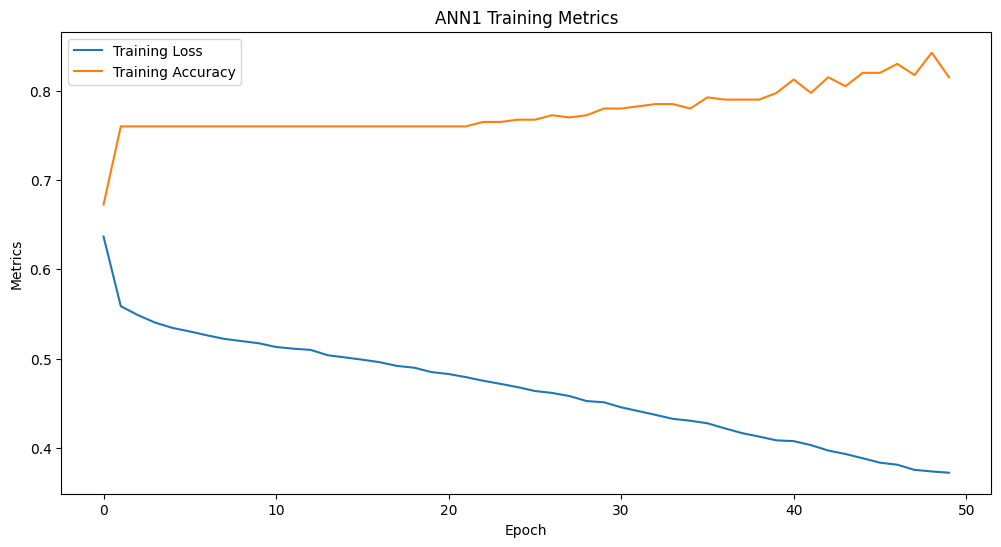

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(ANN1_history.history['loss'], label='Training Loss')
plt.plot(ANN1_history.history['accuracy'], label='Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Metrics')
plt.title('ANN1 Training Metrics')
plt.legend()
plt.show()

In [ ]:
ANN2 = Sequential()
ANN2.add(layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
ANN2.add(layers.Dense(32, activation='relu'))
ANN2.add(layers.Dense(16, activation='relu'))
ANN2.add(layers.Dense(1, activation='sigmoid'))

In [ ]:
ANN2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
ANN2_history = ANN2.fit(X_train, y_train, epochs=100,validation_data=(X_test,y_test))

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.7451 - loss: 0.6081 - val_accuracy: 0.7200 - val_loss: 0.6015
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7502 - loss: 0.5584 - val_accuracy: 0.7200 - val_loss: 0.6083
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7756 - loss: 0.5286 - val_accuracy: 0.7200 - val_loss: 0.6072
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7492 - loss: 0.5476 - val_accuracy: 0.7200 - val_loss: 0.6015
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7613 - loss: 0.5325 - val_accuracy: 0.7200 - val_loss: 0.6071
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7571 - loss: 0.5320 - val_accuracy: 0.7200 - val_loss: 0.6070
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7581 - loss: 0.5200 - val_accuracy: 0.7200 - val_loss: 0.6074
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7469 - loss: 0.5274 - val_accuracy: 0.7200 

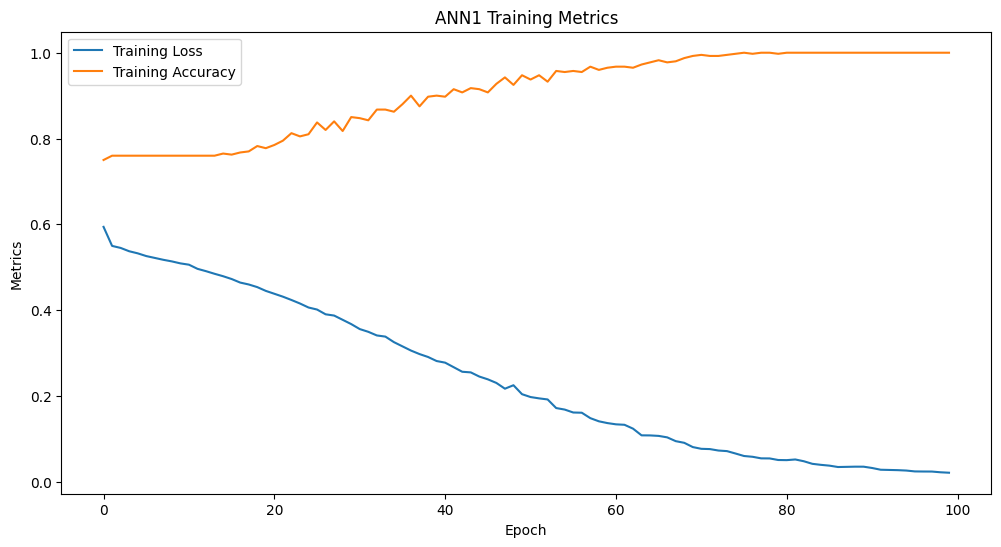

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(ANN2_history.history['loss'], label='Training Loss')
plt.plot(ANN2_history.history['accuracy'], label='Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Metrics')
plt.title('ANN1 Training Metrics')
plt.legend()
plt.show()

In [ ]:
loss, accuracy = ANN2.evaluate(X_test, y_test)
print(f'ANN2 Test Accuracy: {accuracy:.4f}')

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6616 - loss: 1.8418 
ANN2 Test Accuracy: 0.6800


In [ ]:
ANN2 = Sequential()
ANN2.add(layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
ANN2.add(layers.Dense(32, activation='relu'))
ANN2.add(layers.Dense(16, activation='relu'))
ANN2.add(layers.Dense(1, activation='sigmoid'))

ANN2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

ANN2_history = ANN2.fit(X_train, y_train, epochs=100,validation_data=(X_test,y_test))

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.3704 - loss: 0.7309 - val_accuracy: 0.7100 - val_loss: 0.6667
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7315 - loss: 0.6509 - val_accuracy: 0.7200 - val_loss: 0.6326
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7339 - loss: 0.6191 - val_accuracy: 0.7200 - val_loss: 0.6104
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7815 - loss: 0.5657 - val_accuracy: 0.7200 - val_loss: 0.5984
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7592 - loss: 0.5632 - val_accuracy: 0.7200 - val_loss: 0.5976
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7662 - loss: 0.5446 - val_accuracy: 0.7200 - val_loss: 0.6014
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7249 - loss: 0.5827 - val_accuracy: 0.7200 - val_loss: 0.6016
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7742 - loss: 0.5266 - val_accuracy: 0.7200 - 

In [ ]:
loss, accuracy = ANN2.evaluate(X_test, y_test)
print(f'ANN2 Test Accuracy: {accuracy:.4f}')

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6303 - loss: 1.4054
ANN2 Test Accuracy: 0.6200


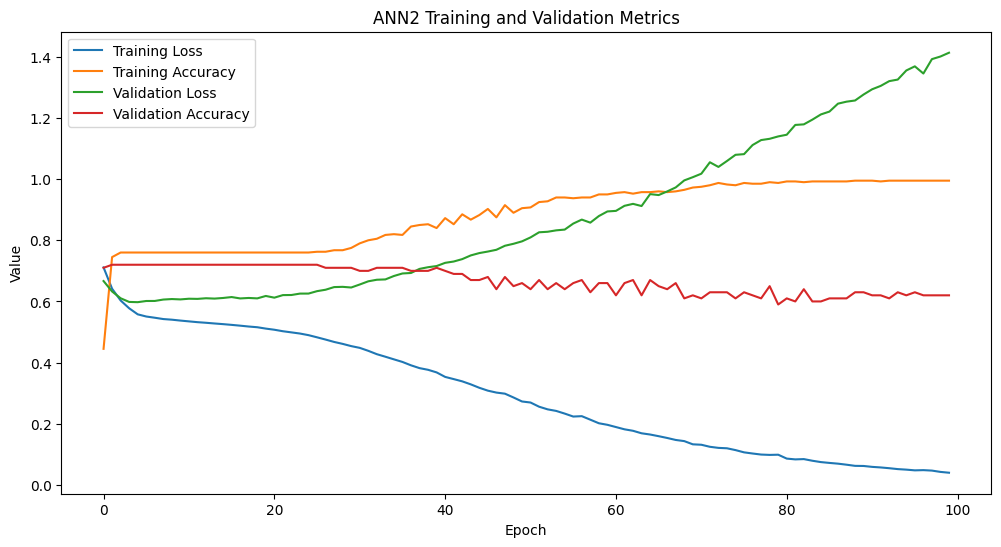

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(ANN2_history.history['loss'], label='Training Loss')
plt.plot(ANN2_history.history['accuracy'], label='Training Accuracy')
plt.plot(ANN2_history.history['val_loss'], label='Validation Loss')
plt.plot(ANN2_history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.title('ANN2 Training and Validation Metrics')
plt.legend()
plt.show()

In [ ]:
ANN_tuned = Sequential()
ANN_tuned.add(layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)))
ANN_tuned.add(layers.Dropout(0.3))
ANN_tuned.add(layers.Dense(64, activation='relu'))
ANN_tuned.add(layers.Dropout(0.3))
ANN_tuned.add(layers.Dense(32, activation='relu'))
ANN_tuned.add(layers.Dropout(0.2))
ANN_tuned.add(layers.Dense(1, activation='sigmoid'))

ANN_tuned.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

ANN_tuned_history = ANN_tuned.fit(X_train, y_train, epochs=100, validation_data=(X_test, y_test), verbose=0)

In [ ]:
loss_tuned, accuracy_tuned = ANN_tuned.evaluate(X_test, y_test)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5879 - loss: 0.9098


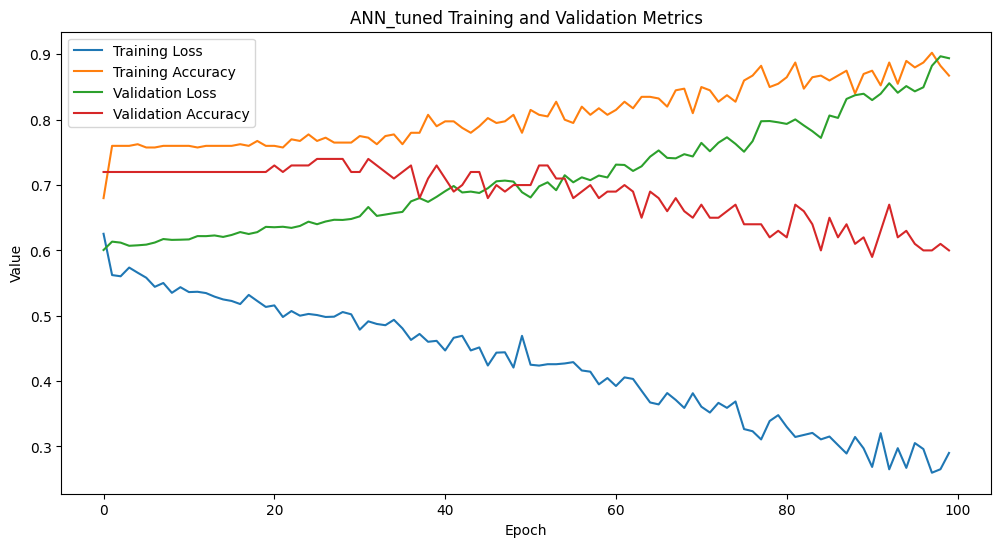

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(ANN_tuned_history.history['loss'], label='Training Loss')
plt.plot(ANN_tuned_history.history['accuracy'], label='Training Accuracy')
plt.plot(ANN_tuned_history.history['val_loss'], label='Validation Loss')
plt.plot(ANN_tuned_history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.title('ANN_tuned Training and Validation Metrics')
plt.legend()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier

# Features & target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Column separation
num_cols = X.select_dtypes(include=['int64','float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

# Numerical pipeline
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline
cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Preprocessor
preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Model (changed from Logistic/KNN → RandomForest)
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=900,
        max_depth=10,
        class_weight='balanced',
        random_state=250
    ))
])

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.74


In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print("Cross-Validation Accuracy:", scores.mean())


Cross-Validation Accuracy: 0.692


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier

# 1. Load Data
df = pd.read_csv('patient_churn_dataset.csv')
df = df.drop('Patient_ID', axis=1)

# 2. Advanced Feature Engineering (Crucial for >85% accuracy)
# Calculate the ratio of missed appointments to total visits
df['Missed_Visit_Ratio'] = df['Missed_Appointments'] / (df['Visits_Last_Year'] + 1)
# Interaction between satisfaction and bill amount (high bills + low satisfaction = churn)
df['Bill_Dissatisfaction'] = df['Total_Bill_Amount'] / (df['Satisfaction_Score'] + 0.1)
# Tenure relative to age
df['Tenure_Age_Ratio'] = df['Tenure_Months'] / (df['Age'] + 1)

# 3. Features & Target
X = df.drop('Churn', axis=1)
y = df['Churn']

# 4. Column separation
num_cols = X.select_dtypes(include=['int64','float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

# 5. Optimized Pipelines
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

# 6. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 7. High-Performance Model Configuration
# We increase n_estimators and adjust min_samples_leaf to prevent overfitting
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=1200,
        max_depth=None,           # Allow nodes to expand until pure
        min_samples_split=2,
        min_samples_leaf=1,
        bootstrap=True,
        max_features='sqrt',
        class_weight='balanced_subsample', # Better handling of class imbalance
        random_state=42,
        n_jobs=-1                 # Use all CPU cores for speed
    ))
])

# 8. Train & Evaluate
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"Final Accuracy: {accuracy_score(y_test, y_pred):.4f}")

Final Accuracy: 0.7600
